In [17]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import re
from sklearn.preprocessing import StandardScaler


con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, value, delimit_value, delimit_value2,analysis, protein_value, manual_classification as label 
                 FROM protein_data 
                 WHERE manual_classification IS NOT NULL 
                 AND value IS NOT NULL
                 AND delimit_value IS NOT NULL
                 AND delimit_value2 IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()

con.close()


def extract_relevant_values(analysis_list, value_list, relevant):
    # Skapa dict från analysis -> value för denna rad
    mapping = dict(zip(analysis_list, value_list))
    
    # Plocka ut relevanta värden i fast ordning
    return [mapping.get(code, np.nan) for code in relevant]

def extract_fractions(delimit_list):
    fractions = []
    for item in delimit_list:
        match = re.search(r'(\d+\.?\d*)\s*%', str(item))
        if match:
            fractions.append(float(match.group(1)))
    return fractions

def clean_value(val):
    if val is None or val == '' or val == 'NA' or val == 'NEG':
        return np.nan
    try:
        return float(str(val).replace('<', '').replace('>', '').strip())
    except:
        return np.nan

def clean_protein_values(val_list):
    return [clean_value(v) for v in val_list]

#value
df = df[ df['value'].apply(len) == 301 ] #vaska de rader där value inte har rätt längd (typ bara en korrupt rad)
df['value'] = df['value'].apply(lambda x: x[:300])

#delimit_value
df['delimit_value'] = df['delimit_value'].apply(extract_fractions)
df = df[ df['delimit_value'].apply(len) == 6]

#delimit_value2
df = df[ df['delimit_value2'].apply(len) == 15]

#hämta ut protein-value
relevant_anlysis = ['0054','0055','0056','0058','0062','0064','0065','0066']
df['protein_value'] = df.apply(
    lambda row: extract_relevant_values(
        row['analysis'], 
        row['protein_value'], 
        relevant_anlysis
    ), 
    axis=1
)
df['protein_value'] = df['protein_value'].apply(clean_protein_values)

X_curve     = np.array(df['value'].tolist(),         dtype=np.float32)  # (n, 300)
X_fractions = np.array(df['delimit_value'].tolist(),  dtype=np.float32)  # (n, 6)
X_delimit2  = np.array(df['delimit_value2'].tolist(), dtype=np.float32)  # (n, 15)
#X_protein   = np.array(df['protein_value'].tolist(),  dtype=np.float32)  # (n, 8)

X = np.concatenate([X_curve, X_fractions, X_delimit2], axis=1)  # (n, 329)
y = np.array(df['label'].values, dtype=np.int64)


print(X.shape) 
print(y.shape)  

# Kolla att det inte finns NaN eller inf
print(f"NaN: {np.isnan(X).sum()}")
print(f"Inf: {np.isinf(X).sum()}")

# Kolla klassbalansen
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    print(f"Label {val}: {count} ({count/len(y)*100:.1f}%)")



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(134299, 321)
(134299,)
NaN: 0
Inf: 0
Label 0: 106177 (79.1%)
Label 1: 28122 (20.9%)


In [18]:

ids = df['id'].values

# Först: låt 15% vara test-set
ids_temp, ids_test, X_temp, X_test, y_temp, y_test = train_test_split(
    ids, X, y, test_size=0.15, random_state=42, stratify=y
)

# Sedan: dela resten i träning/validering (0.1765 ≈ 15% av totalen)
ids_train, ids_val, X_train, X_val, y_train, y_val = train_test_split(
    ids_temp, X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# Normalisera bara de extra features, inte kurvan
scaler = StandardScaler()
X_train[:, 300:] = scaler.fit_transform(X_train[:, 300:])
X_val[:, 300:]   = scaler.transform(X_val[:, 300:])
X_test[:, 300:]  = scaler.transform(X_test[:, 300:])

X_train = torch.tensor(X_train,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)

X_val = torch.tensor(X_val,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.long)

X_test = torch.tensor(X_test,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.long)


print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(y):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(y):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(y):.0%})")

print(torch.isnan(X_train).sum())
print(torch.isinf(X_train).sum())

Träning:     94005 (70%)
Validering:  20149 (15%)
Test:        20145 (15%)
tensor(0)
tensor(0)


In [19]:
batch_sz = 256  # ökad från 64

train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_sz, shuffle=True)
val_dataloader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=batch_sz)
test_dataloader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=batch_sz)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class CNN1D(nn.Module):
    def __init__(self, extra_features=21):
        super().__init__()
        
        # CNN-del för kurvan (300 punkter)
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),                              # 300 -> 150
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),                              # 150 -> 75
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),                              # 75 -> 37
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 37 + 21, 128),
            nn.ReLU(),
            nn.Dropout(0.4),                              # högre dropout
            nn.Linear(128, 2)
        )
    
    def forward(self, x):
        curve = x[:, :300].unsqueeze(1)  # (batch, 1, 300)
        extra = x[:, 300:]               # (batch, 21)
        
        conv_out = self.conv(curve)      # (batch, 128, 37)
        conv_out = conv_out.flatten(1)   # (batch, 128*37)
        
        combined = torch.cat([conv_out, extra], dim=1)
        return self.fc(combined)

def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def validate(val_dataloader, model, loss_fn):
    size = len(val_dataloader.dataset)
    num_batches = len(val_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in val_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct, test_loss)

def test(test_dataloader, model, loss_fn):
    size = len(test_dataloader.dataset)
    num_batches = len(test_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct, test_loss)

model = CNN1D(extra_features=21).to(device)
pos_weight = torch.tensor([1.0, 3.0]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # L2 regularisering
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Antal parametrar: {total_params:,}")

Using mps device
CNN1D(
  (conv): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=2389, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)
Antal parametrar: 315,106


In [20]:
## KÖR DETTA BLOCKET FÖR ATT TRÄNA! Annars kör nästa block och läs in vikterna!
epochs = 50
accuracies = []
validation_losses = []
for t in range(epochs):
    train(train_dataloader, model, loss_fn, optimizer)
    (accuracy,avg_loss) = validate(val_dataloader, model, loss_fn)
    scheduler.step(avg_loss)
    print(f"Epooch {t}, accuracy: {accuracy}, Avg loss: {avg_loss}")
    accuracies.append(accuracy)
    validation_losses.append(avg_loss)
print("Done!")

torch.save(model.state_dict(), "1Dcnn.pth")
print("Saved PyTorch Model State to 1Dcnn.pth")


Epooch 0, accuracy: 95.26031068539382, Avg loss: 0.18717146674288979
Epooch 1, accuracy: 96.44647377041045, Avg loss: 0.15267228486039972
Epooch 2, accuracy: 96.35217628666435, Avg loss: 0.18591212273775776
Epooch 3, accuracy: 96.5308452032359, Avg loss: 0.13894140852403036
Epooch 4, accuracy: 95.8806888679339, Avg loss: 0.13881108909845352
Epooch 5, accuracy: 96.60032755968038, Avg loss: 0.1841635459774657
Epooch 6, accuracy: 96.36706536304531, Avg loss: 0.13691928067916556
Epooch 7, accuracy: 96.16358131917217, Avg loss: 0.1370982489065279
Epooch 8, accuracy: 96.71447714526775, Avg loss: 0.14126036278431928
Epooch 9, accuracy: 96.49114099955332, Avg loss: 0.13311223261341265
Epooch 10, accuracy: 96.64995781428358, Avg loss: 0.14076603383203096
Epooch 11, accuracy: 96.31247208298178, Avg loss: 0.13436550713038142
Epooch 12, accuracy: 96.2429897265373, Avg loss: 0.1342102748495114
Epooch 13, accuracy: 95.99483845352127, Avg loss: 0.13803959298360197
Epooch 14, accuracy: 96.451436795870

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("1Dcnn.pth", weights_only=True))

# Samla alla prediktioner
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        all_preds.extend(pred.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
# Rapport
print(classification_report(all_labels, all_preds, target_names=['Negativ', 'Positiv']))

# Konfusionsmatris
print(confusion_matrix(all_labels, all_preds))

(test_accuracy, test_loss) = test(test_dataloader,model,loss_fn)
print(f"Resultat på testdatan: accuracy: {test_accuracy}, Avg loss: {test_loss}")


              precision    recall  f1-score   support

     Negativ       0.98      0.98      0.98     15927
     Positiv       0.92      0.93      0.93      4218

    accuracy                           0.97     20145
   macro avg       0.95      0.96      0.95     20145
weighted avg       0.97      0.97      0.97     20145

[[15605   322]
 [  287  3931]]
Resultat på testdatan: accuracy: 96.97691734921817, Avg loss: 0.14239306446117692


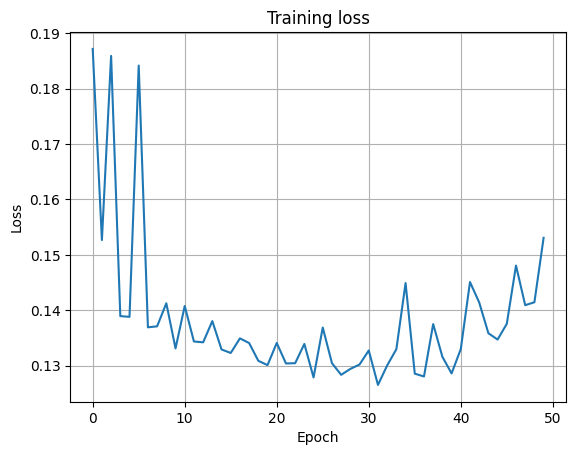

In [22]:
# Analys av hur träningen gick
import matplotlib.pyplot as plt

plt.plot(validation_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)
plt.show()

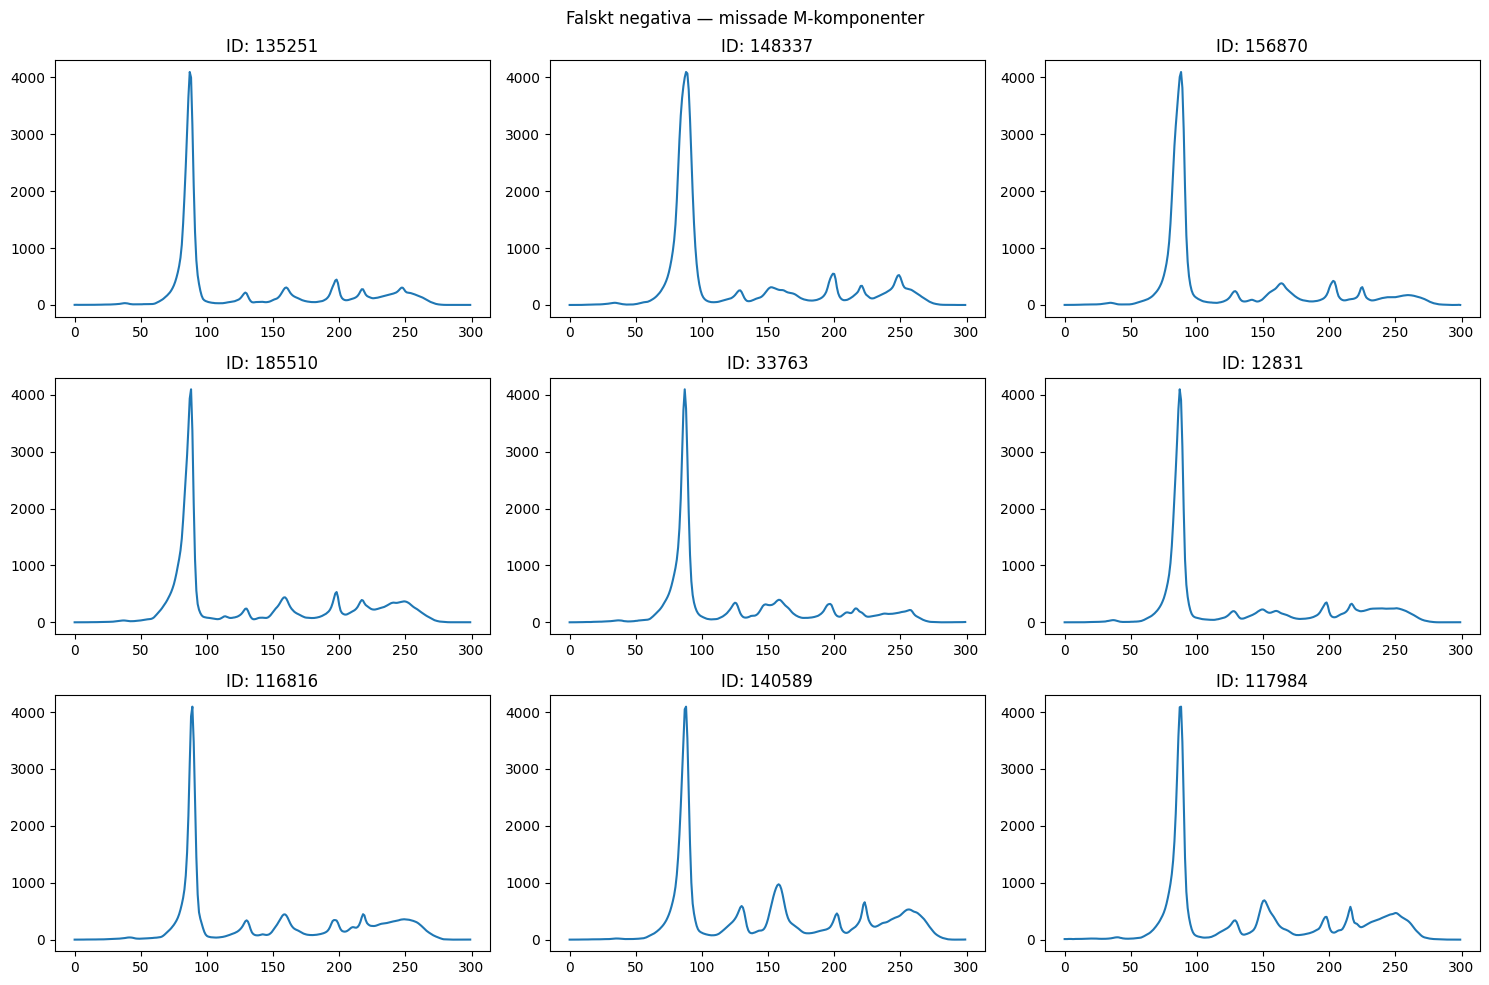

In [25]:
fn_idx = np.where((all_labels == 1) & (all_preds == 0))[0]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    if i >= len(fn_idx):
        break
    idx = fn_idx[i]
    curve = X_val[idx, :300]
    ax.plot(curve)
    ax.set_title(f"ID: {ids_val[idx]}")

plt.suptitle("Falskt negativa — missade M-komponenter")
plt.tight_layout()
plt.show()